# Early leaf discoloration signals unprecedented 2026 drought stress in Switzerland's European beech forests
by Colin Bloom, Dominique Weber, Marius Rüetschi, Frank Krumm, and Andri Baltensweiler

*This Jupyter Notebook runs the full analysis workflow. Run it from the `notebooks/` directory of this repository (paths below are relative to that location).*

Generally each step should be run sequentially.
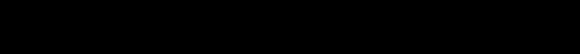
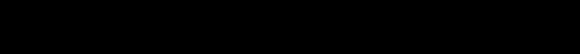

## Environment setup
*Note: This cell must be run before any other cell*

In [1]:
import os
from datetime import date

from src.disco_ch.force_tsi_batch import run_tsi_tiles
from src.disco_ch.force_pull import run_tsa_workflow_tiled

## User defined parameters
*Note: This cell must be run before skipping any other cells below*

In [2]:
force_directory_2018 = r"B:\bloomc\DiscoCH_2026_08_03\FORCE\level_3_2018_tiled"
force_directory_2026 = r"B:\bloomc\DiscoCH_2026_08_03\FORCE\level3_tss"

force_tiles_to_process = r"G:\1_cbloom\Projects\2025_01_12_VHI\DiscoCH\data\CH_FORCE_Grids.csv"

output_dir = r"B:\bloomc\DiscoCH_2026_08_03\FORCE"

## FORCE time series

In [3]:
force_output = os.path.join(output_dir, 'FORCE')
os.makedirs(force_output, exist_ok=True)

### 2018

#### RBF interpolation

Single pixel example

In [ ]:
from src.disco_ch.force_tsi_plot import plot_pixel

data26 = r"B:\bloomc\DiscoCH_2026_08_03\FORCE\level3_tss\X0056_Y0061\20260101-20261231_001-365_HL_TSA_SEN2L_EVI_TSS.tif"
data18 = r"B:\bloomc\DiscoCH_2026_08_03\FORCE\level_3_2018_tiled\X0056_Y0061\2018-2018_001-365_HL_TSA_SEN2L_EVI_TSS.tif"

row=2425 # 2429
col=2156 # 2123

fig, (row, col), dates, cube, cleaned, removed = plot_pixel(
  data18, row=row, col=col,
  rbf_sigma=(10, 20, 30, 40, 50), rbf_cutoff=0.95,
  above_noise=3.0, below_noise=1.0, int_day=5,
)

fig.show()

fig, (row, col), dates, cube, cleaned, removed = plot_pixel(
  data26, row=row, col=col,
  rbf_sigma=(10, ), rbf_cutoff=0.95,
  above_noise=3.0, below_noise=1.0, int_day=5,
)
fig.show()


In [ ]:
rbf_output = os.path.join(force_output, 'level4_rbf/2018')
os.makedirs(rbf_output, exist_ok=True)

vi_keys_2018 = {
    "NDVI": "NDV",
    "EVI": "EVI",
    "NDMI": "NDM",
    "CIRE": "CRE",
    "CCI": "CCI",
}

results = run_tsi_tiles(
    force_directory_2018,
    vi_keys_2018,
    out_dir=rbf_output,
    date_range=(date(2018, 1, 1), date(2018, 12, 31)),
    doy_range=(1, 365), int_day=5,
    rbf_sigma=(10, 20, 30, 50), rbf_cutoff=0.95,
    above_noise=3.0, below_noise=1.0,
    chunk_size=512, max_workers=5,
    skip_existing=True,
    tiles_csv=force_tiles_to_process,  # only these Tile_IDs are processed
    blas_threads=1,        # new — caps BLAS to 1 thread/call, avoids oversubscription
    verbose_chunks=True,   # new — prints per-chunk progress so you can see it moving
    despike=False,
)

for tile_id, by_vi in results.items():
    for vi, (tss_path, out_path, status) in by_vi.items():
        if status != "written":
            print(f"{tile_id}/{vi}: {status}")

#### DiscoCH

In [ ]:
rbf_output = rbf_output if "rbf_output" in dir() else os.path.join(force_output, 'level4_rbf/2018')
discoCH_output = os.path.join(force_output, 'output/2018')
os.makedirs(discoCH_output, exist_ok=True)
minmax_dir = os.path.join(force_output, 'minmax/2018')
os.makedirs(minmax_dir, exist_ok=True)

# Define your dates of interest (YYYY-MM-DD)
start_date = '2018-03-01'
end_date = '2018-09-30'

# Root directory containing the X####_Y#### tile folders
rbf_output = rbf_output if "rbf_output" in dir() else os.path.join(output_dir, "level4_rbf/2018")

vi_pattern_template="{year}*_{vi}_TSS_TSI.tif"

# Forest Mask (national/AOI extent -- each tile clips its own region out of this automatically)
forest_mask = None # r"G:\1_cbloom\Projects\2025_01_12_VHI\DiscoCH\data\DRAINS_Forest_Mask.tif"

# NaN value template for initializing min and max values (national/AOI extent, same as forest_mask)
ch_template = r"G:\1_cbloom\Projects\2025_01_12_VHI\DiscoCH\data\CH_NoValue_255.tif"

disco_model = r'G:\1_cbloom\Projects\2025_01_12_VHI\DiscoCH\data\empirical_discoloration_model_pipeline_2025_6_2.pkl'

# Only dates falling in these months get normalized + run through the
# model (min/max still updates for every processed date)
model_months = (5, 6, 7, 8, 9)

# Plot each individual tile's per-date output as it's produced
plot_tile_results = False

# Plot the final mosaicked per-date output after all tiles are merged
plot_mosaic_results = False

vi_keys_2018 = {
    "NDVI": "NDV",
    "EVI":  "EVI",
    "NDMI": "NDM",
    "CIRE": "CRE",
    "CCI":  "CCI",
}

# Get year from date of interest
year_of_interest = int(start_date.split("-")[0])

run_tsa_workflow_tiled(
    root_dir=rbf_output,
    year_of_interest=year_of_interest,
    forest_mask_path=forest_mask,
    template_path=ch_template,
    existing_data_root=minmax_dir,
    output_root=discoCH_output,
    disco_model=disco_model,
    model_months=model_months,
    vi_keys=vi_keys_2018,
    start_date=start_date,
    end_date=end_date,
    plot_tile_results=plot_tile_results,
    plot_mosaic_results=plot_mosaic_results,
    vi_pattern_template=vi_pattern_template,
    max_workers=10,
    grid_csv=force_tiles_to_process,
)

### 2026

#### RBF interpolation

In [ ]:
# Create output directory
rbf_output = os.path.join(force_output, 'level4_rbf/2024')
os.makedirs(rbf_output, exist_ok=True)

vi_keys_2026 = {
    "NDVI": "NDVI",
    "EVI": "EVI",
    "NDMI": "NDMI",
    "CIRE": "CIre",
    "CCI": "CCI",
}

results = run_tsi_tiles(
    force_directory_2026,
    vi_keys_2026,
    out_dir=rbf_output,
    date_range=(date(2024, 1, 1), date(2024, 12, 31)),
    doy_range=(1, 365), int_day=5,
    rbf_sigma=(10, ), rbf_cutoff=0.95,
    above_noise=3.0, below_noise=1.0,
    chunk_size=512, max_workers=10,
    skip_existing=True,
    tiles_csv=force_tiles_to_process,  # only these Tile_IDs are processed
    blas_threads=1,        # new — caps BLAS to 1 thread/call, avoids oversubscription
    verbose_chunks=True,   # new — prints per-chunk progress so you can see it moving
    despike=False,
)

for tile_id, by_vi in results.items():
    for vi, (tss_path, out_path, status) in by_vi.items():
        if status != "written":
            print(f"{tile_id}/{vi}: {status}")

#### DiscoCH

In [8]:
rbf_output = rbf_output if "rbf_output" in dir() else os.path.join(force_output, 'level4_rbf/2026')
discoCH_output = os.path.join(force_output, 'output/2026')
os.makedirs(discoCH_output, exist_ok=True)
minmax_dir = os.path.join(force_output, 'minmax/2026')
os.makedirs(minmax_dir, exist_ok=True)

# Define your dates of interest (YYYY-MM-DD)
start_date = '2026-03-01'
end_date = '2026-08-17'

# Root directory containing the X####_Y#### tile folders
rbf_output = rbf_output if "rbf_output" in dir() else os.path.join(output_dir, "level4_rbf/2026")

vi_pattern_template="{year}*_{vi}_TSS_TSI.tif"

# Local directory for per-tile min/max caches + metadata
minmax_dir = os.path.join(force_output, 'minmax/2026')
os.makedirs(minmax_dir, exist_ok=True)

# Forest Mask (national/AOI extent -- each tile clips its own region out
# of this automatically)
forest_mask = None # r"G:\1_cbloom\Projects\2025_01_12_VHI\DiscoCH\data\DRAINS_Forest_Mask.tif"

# NaN value template for initializing min and max values (national/AOI
# extent, same as forest_mask)
ch_template = r"G:\1_cbloom\Projects\2025_01_12_VHI\DiscoCH\data\CH_NoValue_255.tif"

disco_model = r'G:\1_cbloom\Projects\2025_01_12_VHI\DiscoCH\data\empirical_discoloration_model_pipeline_2025_6_2.pkl'

# Only dates falling in these months get normalized + run through the
# model (min/max still updates for every processed date)
model_months = (6, 7, 8)

# Plot each individual tile's per-date output as it's produced
plot_tile_results = False

# Plot the final mosaicked per-date output after all tiles are merged
plot_mosaic_results = False

vi_keys_2026 = {
    "NDVI": "NDVI",
    "EVI": "EVI",
    "NDMI": "NDMI",
    "CIRE": "CIre",
    "CCI": "CCI",
}

# Get year from date of interest
year_of_interest = int(start_date.split("-")[0])

run_tsa_workflow_tiled(
    root_dir=rbf_output,
    year_of_interest=year_of_interest,
    forest_mask_path=forest_mask,
    template_path=ch_template,
    existing_data_root=minmax_dir,
    output_root=discoCH_output,
    disco_model=disco_model,
    model_months=model_months,
    vi_keys=vi_keys_2026,
    start_date=start_date,
    end_date=end_date,
    plot_tile_results=plot_tile_results,
    plot_mosaic_results=plot_mosaic_results,
    vi_pattern_template=vi_pattern_template,
    max_workers=10,
    grid_csv=force_tiles_to_process,
)

Found 69 tile folders under B:\bloomc\DiscoCH_2026_08_03\FORCE\FORCE\level4_rbf/2026
Processing tiles with max_workers=10 (dask_threads_per_worker=2)
Per-tile logs: B:\bloomc\DiscoCH_2026_08_03\FORCE\FORCE\output/2026\logs
  [1/69, 0.1 min elapsed, ~5.4 min remaining] X0052_Y0065: done -- B:\bloomc\DiscoCH_2026_08_03\FORCE\FORCE\output/2026\X0052_Y0065
  [2/69, 0.1 min elapsed, ~2.7 min remaining] X0051_Y0066: done -- B:\bloomc\DiscoCH_2026_08_03\FORCE\FORCE\output/2026\X0051_Y0066
  [3/69, 0.1 min elapsed, ~1.7 min remaining] X0052_Y0066: done -- B:\bloomc\DiscoCH_2026_08_03\FORCE\FORCE\output/2026\X0052_Y0066
  [4/69, 0.1 min elapsed, ~1.3 min remaining] X0053_Y0063: done -- B:\bloomc\DiscoCH_2026_08_03\FORCE\FORCE\output/2026\X0053_Y0063
  [5/69, 0.1 min elapsed, ~1.0 min remaining] X0053_Y0064: done -- B:\bloomc\DiscoCH_2026_08_03\FORCE\FORCE\output/2026\X0053_Y0064
  [6/69, 0.1 min elapsed, ~0.8 min remaining] X0052_Y0064: done -- B:\bloomc\DiscoCH_2026_08_03\FORCE\FORCE\output/20

## swissEO time series

In [ ]:
swissEO_output = os.path.join(output_dir, 'swissEO')
os.makedirs(swissEO_output, exist_ok=True)

### 2018

#### RBF interpolation

#### DiscoCH

### 2026

#### RBF interpolation

#### DiscoCH

## DiscoCH Validation: Compare 2018 FORCE DiscoCH outputs to Bloom et al. (2026) outputs

## swissEO Validation: Compare 2026 FORCE DiscoCH outputs to 2026 swissEO DiscoCH outputs

## Global Statistics

## Examples